# Hybrid Machine Learning Approach for Fraud Detection in Financial Transactions
## Vesta's real-world e-commerce transactions Dataset
**Dataset:** Vesta's real-world e-commerce transactions (Kaggle)

In [ ]:
# =========================================
# 1. Imports
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import pickle
import gc
import psutil
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [2]:
# ================================
# 2. Load Dataset
# ================================
train_trans = pd.read_csv("transaction.csv")
train_id = pd.read_csv("identity.csv")

df = train_trans.merge(train_id, on="TransactionID", how="left")
print(df.shape)
print(df.head())
print(df.info())

(590540, 434)
   TransactionID  isFraud  TransactionDT  TransactionAmt ProductCD  card1  \
0        2987000        0          86400            68.5         W  13926   
1        2987001        0          86401            29.0         W   2755   
2        2987002        0          86469            59.0         W   4663   
3        2987003        0          86499            50.0         W  18132   
4        2987004        0          86506            50.0         H   4497   

   card2  card3       card4  card5  ...                id_31  id_32  \
0    NaN  150.0    discover  142.0  ...                  NaN    NaN   
1  404.0  150.0  mastercard  102.0  ...                  NaN    NaN   
2  490.0  150.0        visa  166.0  ...                  NaN    NaN   
3  567.0  150.0  mastercard  117.0  ...                  NaN    NaN   
4  514.0  150.0  mastercard  102.0  ...  samsung browser 6.2   32.0   

       id_33           id_34  id_35 id_36 id_37  id_38  DeviceType  \
0        NaN             N

In [3]:
# ================================
# 3. Data Preprocessing
# ================================

# Null values
print(df.isnull().sum())

# Handle missing
df.fillna(-999, inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Encode categorical
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype('category').cat.codes

# Target
y = df["isFraud"]
X = df.drop(["isFraud", "TransactionID"], axis=1)

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

TransactionID          0
isFraud                0
TransactionDT          0
TransactionAmt         0
ProductCD              0
                   ...  
id_36             449555
id_37             449555
id_38             449555
DeviceType        449730
DeviceInfo        471874
Length: 434, dtype: int64


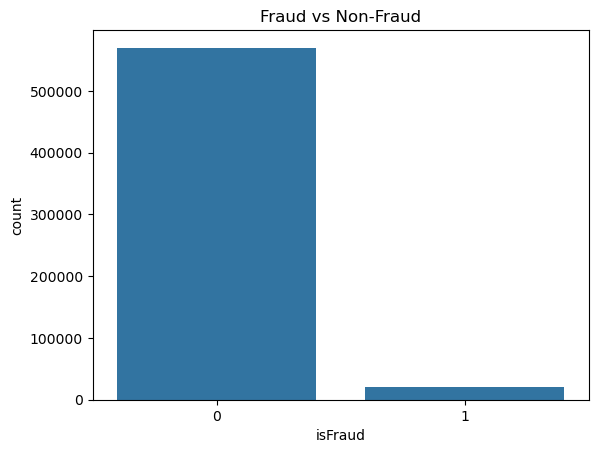

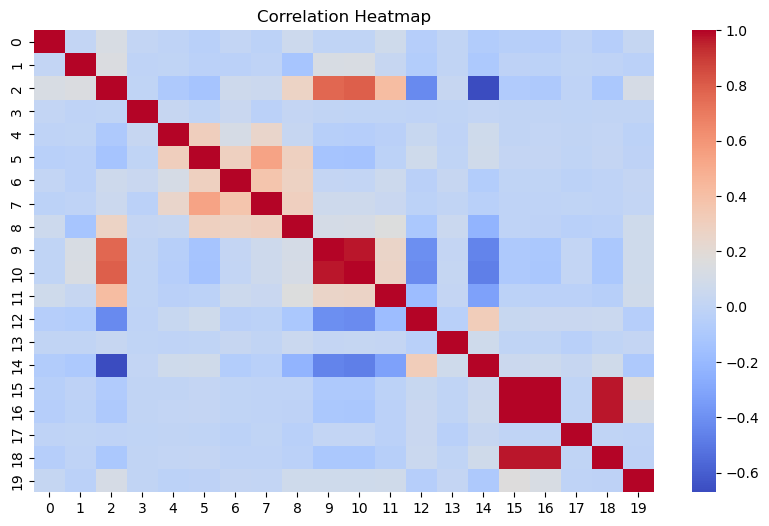

In [4]:
# ================================
# 4. EDA
# ================================
sns.countplot(x=y)
plt.title("Fraud vs Non-Fraud")
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(pd.DataFrame(X_scaled).corr().iloc[:20,:20], cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [5]:
# =========================================
# 5. KMeans Clustering (Feature Engineering)
# =========================================
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

X = pd.DataFrame(X_scaled)
X["Cluster"] = clusters

In [6]:
# =========================================
# 6. Train-Test Split
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [7]:
# =========================================
# 7. SMOTE
# =========================================
# Convert all column names to strings to ensure consistency
X_train.columns = X_train.columns.astype(str)

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# =========================================
# 8. Validation Split (for Optuna)
# =========================================
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_sm, y_train_sm, test_size=0.2, random_state=42
)

In [8]:
# =========================================
# 9. Basic Models (Optimized)
# =========================================

# --- Ensure column names are strings (prevents sklearn bugs) ---
X_train_sm.columns = X_train_sm.columns.astype(str)
X_test.columns = X_test.columns.astype(str)

# --- Reduce memory usage ---
X_train_sm = X_train_sm.astype('float32')
X_test = X_test.astype('float32')

# --- Define lightweight models ---
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=100,              # reduced iterations
        solver='saga',             # memory efficient for large data
        n_jobs=-1,
        class_weight='balanced'
    ),
    
    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,               # reduced depth → less memory
        min_samples_split=20,
        class_weight='balanced'
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=30,           # reduced trees
        max_depth=8,
        n_jobs=-1,
        class_weight='balanced'
    ),
    

}

results = []

def evaluate_and_store(name, model):
    print(f"\n===== {name} =====")
    
    # Train
    model.fit(X_train_sm, y_train_sm)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Some models may not support predict_proba efficiently
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        roc = roc_auc_score(y_test, y_prob)
    else:
        roc = "N/A"
    
    f1 = f1_score(y_test, y_pred)

    print("F1 Score:", f1)
    print("ROC-AUC:", roc)
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))

    results.append((name, f1))

    # --- Free memory after each model ---
    del model
    gc.collect()

# Run models
for name, model in models.items():
    evaluate_and_store(name, model)

# Sort results
results = sorted(results, key=lambda x: x[1], reverse=True)

print("\n===== Final Model Ranking =====")
for r in results:
    print(r)


===== Logistic Regression =====
F1 Score: 0.17131286233391585
ROC-AUC: 0.8233876002814299
Confusion Matrix:
 [[85145 28830]
 [ 1045  3088]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.75      0.85    113975
           1       0.10      0.75      0.17      4133

    accuracy                           0.75    118108
   macro avg       0.54      0.75      0.51    118108
weighted avg       0.96      0.75      0.83    118108


===== Decision Tree =====
F1 Score: 0.3233801879730516
ROC-AUC: 0.8180086440399383
Confusion Matrix:
 [[108029   5946]
 [  2189   1944]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.95      0.96    113975
           1       0.25      0.47      0.32      4133

    accuracy                           0.93    118108
   macro avg       0.61      0.71      0.64    118108
weighted avg       0.95      0.93      0.94    118108


===== Random Fores

In [9]:
# =========================================
# 10. Optuna - XGBoost
# =========================================
def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 120),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "n_jobs": -1,
        "eval_metric": "logloss"
    }
    model = XGBClassifier(**params)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_val)
    return f1_score(y_val, y_pred)

study = optuna.create_study(direction="maximize")
study.optimize(objective_xgb, n_trials=15)

best_xgb = XGBClassifier(**study.best_params)
best_xgb.fit(X_train_sm, y_train_sm)

[I 2026-05-04 10:35:18,891] A new study created in memory with name: no-name-dc384f04-f37f-4afa-9764-04536f0c950f
[I 2026-05-04 10:37:55,762] Trial 0 finished with value: 0.9771224536405212 and parameters: {'n_estimators': 108, 'max_depth': 7, 'learning_rate': 0.1218078260399808}. Best is trial 0 with value: 0.9771224536405212.
[I 2026-05-04 10:39:56,181] Trial 1 finished with value: 0.9446811877606845 and parameters: {'n_estimators': 93, 'max_depth': 8, 'learning_rate': 0.033515039666721216}. Best is trial 0 with value: 0.9771224536405212.
[I 2026-05-04 10:41:26,585] Trial 2 finished with value: 0.905350774237811 and parameters: {'n_estimators': 98, 'max_depth': 4, 'learning_rate': 0.044520724043978326}. Best is trial 0 with value: 0.9771224536405212.
[I 2026-05-04 10:42:59,361] Trial 3 finished with value: 0.9556626966936895 and parameters: {'n_estimators': 52, 'max_depth': 7, 'learning_rate': 0.09871004202656136}. Best is trial 0 with value: 0.9771224536405212.
[I 2026-05-04 10:44:2

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [10]:
# =========================================
# 11. LightGBM
# =========================================
lgbm = LGBMClassifier(n_estimators=100, n_jobs=-1)
lgbm.fit(X_train_sm, y_train_sm)

# =========================================
# 12. Evaluate Advanced Models
# =========================================
evaluate_and_store("XGBoost", best_xgb)
evaluate_and_store("LightGBM", lgbm)



[LightGBM] [Info] Number of positive: 455902, number of negative: 455902
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.379602 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 105577
[LightGBM] [Info] Number of data points in the train set: 911804, number of used features: 433
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000

===== XGBoost =====
F1 Score: 0.6263473053892216
ROC-AUC: 0.9292760822205428
Confusion Matrix:
 [[113520    455]
 [  2041   2092]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99    113975
           1       0.82      0.51      0.63      4133

    accuracy                           0.98    118108
   macro avg       0.90      0.75      0.81    118108
weighted avg       0.98      0.98      0.98    118108


===== L

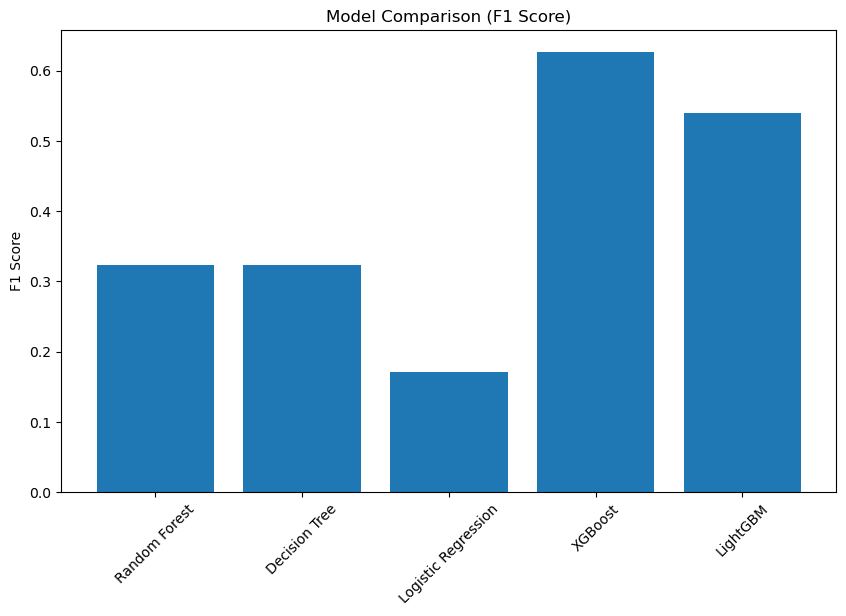

In [11]:
# =========================================
# 13. Final Visualization (ALL MODELS)
# =========================================
model_names = [r[0] for r in results]
f1_scores = [r[1] for r in results]

plt.figure(figsize=(10,6))
plt.bar(model_names, f1_scores)
plt.title("Model Comparison (F1 Score)")
plt.xticks(rotation=45)
plt.ylabel("F1 Score")
plt.show()


In [12]:
# =========================================
# 14. Save Models
# =========================================
pickle.dump(best_xgb, open("xgb_model.pkl", "wb"))
pickle.dump(lgbm, open("lgbm_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))
pickle.dump(kmeans, open("kmeans.pkl", "wb"))

print("\nAll models saved successfully!")


All models saved successfully!
